# 01 · Prepare source data with separate roles

**Goal:** create labeled training lessons and independent data that
measure what each lesson actually teaches.

**Question:** can a short training response tell us which synthetic lesson
will improve an unfamiliar pose estimator on real video?

The source sequence is **00 → 01 → 02 → 03 → 07**. Run 02 once per configured
source student. After the source decision, prepare independent GAVD references
in 04, deploy without reading their labels in 05, and exchange selected lessons
in 08. Explicitly evaluate in 06. These notebooks contain no precomputed
research results or substitute models.

[Proposal](../../../../../../notes/research-agenda/proposals/synthetic-training-selection.md)
· [Notebook guide](../../../../../../notebooks/synthetic_training/README.md)
· [HAIC setup and launch commands](../../../../../../slurm/synthetic-training/README.md)

In [1]:
from pathlib import Path
import json
import os
import sys
from time import perf_counter

root_override = os.environ.get("GAVD6_ROOT")
candidates = ([Path(root_override).expanduser()] if root_override else
              [Path.cwd(), *Path.cwd().parents])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / "src/gavd6_sjepa").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set GAVD6_ROOT to the gavd6 checkout.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
os.environ.setdefault("GAVD6_ROOT", str(PROJECT_ROOT))
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, SVG, display
from gavd6_sjepa.research_directions.synthetic_training.config import RunConfig
from gavd6_sjepa.research_directions.synthetic_training import workflow

cfg = RunConfig.from_env()
RUN_ROOT = cfg.root
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

def show_result(result):
    # Display the tables and artifact paths returned by a workflow stage.
    if isinstance(result, pd.DataFrame):
        display(result)
    elif isinstance(result, dict):
        for name, value in result.items():
            display(Markdown(f"### {name.replace('_', ' ')}"))
            if isinstance(value, pd.DataFrame):
                display(value)
            elif isinstance(value, Path) and value.suffix == ".svg" and value.is_file():
                display(SVG(filename=str(value)))
            else:
                print(json.dumps(value, indent=2, default=str) if isinstance(value, (list, dict)) else value)
    else:
        print(result)

print(f"Run: {RUN_ROOT}")
print(f"Context representation: {cfg.context_kind}; device: {cfg.device}")

Run: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/synthetic-training/pilot-01
Context representation: vjepa; device: cuda


## 1. Separate training from measurement

The common probe, eight lessons, and labeled diagnostic bank use
different source-training motions. Context clips tell the selector
which environment a student will face. Reference clips measure the
resulting accuracy. The context and reference motions are separate;
changing a camera or texture does not create a new independent motion.

The existing AMASS subject registry and split assignments determine
eligibility. Validation contexts and references use excluded people.
Every rendering of a motion keeps its original role.

In [2]:
display(pd.DataFrame([
    ("probe", "One shared short update", "Labels train the student"),
    ("lesson", "Candidate training choices", "Labels train the student"),
    ("diagnostic", "Known synthetic weaknesses", "Error summaries are selector inputs"),
    ("context", "Simulated deployment collection", "Reference coordinates are not selector inputs"),
    ("reference", "Measure lesson utility", "Errors supply source teacher targets only"),
    ("COCO replay", "Retain real-image pose competence", "Labels train the student"),
], columns=["Data role", "Purpose", "Use of labels"]))

,Data role,Purpose,Use of labels
0,probe,One shared short update,Labels train the student
1,lesson,Candidate training choices,Labels train the student
2,diagnostic,Known synthetic weaknesses,Error summaries are selector inputs
3,context,Simulated deployment collection,Reference coordinates are not selector inputs
4,reference,Measure lesson utility,Errors supply source teacher targets only
5,COCO replay,Retain real-image pose competence,Labels train the student


## 2. Render the lesson library and prepare replay

Each rendered RGB image has a fixed person crop, projected landmarks,
visibility flags, and its motion/person provenance. Texture, background,
and viewpoint variation should not accidentally identify the answer.
Full-body AMASS meshes support shoulders, arms, hips, knees, and ankles.

The renderer requires compatible UV topology and real texture images;
it does not silently replace these with a colored stick figure. View,
resolution, blur, and occlusion are controlled appearance conditions,
not simulated clinical diagnoses.

COCO replay is a fixed set of labeled real examples. At the default
mixture, synthetic branches use 90% replay and 10% lesson images.
Replay-only fills every slot with real images, so it sees more real
examples at the same total update budget.

In [3]:
started = perf_counter()
prepared = workflow.prepare_data(cfg)
show_result(prepared)
print(f"Data preparation took {(perf_counter() - started) / 60:.1f} minutes.")

/hai/scratch/tedmui/envs/synthetic-training-cu124/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/hai/scratch/tedmui/envs/synthetic-training-cu124/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/hai/users/t/e/tedmui/.local/share/uv/python/cpython-3.11.16-linux-x86_64-gnu/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


/hai/users/t/e/tedmui/.local/share/uv/python/cpython-3.11.16-linux-x86_64-gnu/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


/hai/users/t/e/tedmui/.local/share/uv/python/cpython-3.11.16-linux-x86_64-gnu/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


...

### replay

/hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/synthetic-training/pilot-01/data/replay.csv


### counts

,role,domain_id,frames
0,diagnostic,support,2048
1,lesson,support,2048
2,probe,support,256
3,train_context,front_high_clear_blur,128
4,train_context,front_high_clear_sharp,128
...,...,...,...
94,validation_reference,side_high_occluded_sharp,128
95,validation_reference,side_low_clear_blur,128
96,validation_reference,side_low_clear_sharp,128
97,validation_reference,side_low_occluded_blur,128


Data preparation took 8.2 minutes.


In [4]:
# Inspect saved assignments before spending GPU time on teaching trials.
for name in ("synthetic.csv", "replay.csv"):
    path = RUN_ROOT / "data" / name
    if path.is_file():
        table = pd.read_csv(path)
        display(Markdown(f"### {name}: {len(table):,} frames"))
        display(table.head(8))
        groups = [c for c in ("role", "domain_id", "lesson_id") if c in table]
        if groups:
            display(table.groupby(groups, dropna=False).size().rename("frames").to_frame())

### synthetic.csv: 16,640 frames

,person_id,motion_id,recording_id,domain_id,role,lesson_id,original_split,source_path,source_start_s,source_frame_start,...,label_index,bbox_x1,bbox_y1,bbox_x2,bbox_y2,width,height,texture_path,background_path,landmark_convention
0,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,0,100.0,93.0,161.0,227.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...
1,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,1,100.0,93.0,161.0,227.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...
2,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,2,100.0,93.0,161.0,227.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...
3,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,3,100.0,93.0,161.0,227.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...
4,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,4,100.0,93.0,161.0,228.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...
5,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,5,100.0,93.0,161.0,228.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...
6,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,6,100.0,93.0,161.0,228.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...
7,Eyes_Japan_Dataset::hamada,Eyes_Japan_Dataset/hamada/pose-03-open leg-ham...,1a0215b1166d,support,probe,probe,train,/hai/scratch/tedmui/alexpose/experiments/sjepa...,20.128805,2415.456591,...,7,100.0,93.0,161.0,228.0,256,320,/hai/scratch/tedmui/models/synthetic-rendering...,/hai/scratch/tedmui/models/synthetic-rendering...,projected_smplh_joint_centers_approximate_coco...


frames
role                 domain_id                lesson_id                       
diagnostic           support                  balanced                     256
                                              blur                         256
                                              front                        256
                                              low_resolution               256
                                              low_resolution_occlusion     256
...                                                                        ...
validation_reference side_high_occluded_sharp NaN                          128
                     side_low_clear_blur      NaN                          128
                     side_low_clear_sharp     NaN                          128
                     side_low_occluded_blur   NaN                          128
                     side_low_occluded_sharp  NaN                          128

[113 rows x 1 columns]

### replay.csv: 256 frames

,frame_id,clip_id,frame_index,image_path,label_path,label_index,bbox_x1,bbox_y1,bbox_x2,bbox_y2,width,height,person_id,motion_id,recording_id,domain_id,role,lesson_id,landmark_convention
0,coco_450263_204796,coco_450263,0,/hai/scratch/tedmui/coco/train2017/00000045026...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,6.37,46.16,59.42,243.48,640,480,coco_annotation_204796,NaN,coco_450263,coco,replay,NaN,coco_body12_visible_v2
1,coco_5156_422230,coco_5156,0,/hai/scratch/tedmui/coco/train2017/00000000515...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,461.72,257.37,514.78,384.42,640,480,coco_annotation_422230,NaN,coco_5156,coco,replay,NaN,coco_body12_visible_v2
2,coco_34597_537463,coco_34597,0,/hai/scratch/tedmui/coco/train2017/00000003459...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,181.05,140.65,265.86,425.00,640,425,coco_annotation_537463,NaN,coco_34597,coco,replay,NaN,coco_body12_visible_v2
3,coco_309261_499871,coco_309261,0,/hai/scratch/tedmui/coco/train2017/00000030926...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,265.21,133.87,393.53,285.96,640,423,coco_annotation_499871,NaN,coco_309261,coco,replay,NaN,coco_body12_visible_v2
4,coco_89616_481393,coco_89616,0,/hai/scratch/tedmui/coco/train2017/00000008961...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,87.95,274.18,292.73,638.14,480,640,coco_annotation_481393,NaN,coco_89616,coco,replay,NaN,coco_body12_visible_v2
5,coco_372180_435907,coco_372180,0,/hai/scratch/tedmui/coco/train2017/00000037218...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,273.47,116.11,450.03,351.20,640,427,coco_annotation_435907,NaN,coco_372180,coco,replay,NaN,coco_body12_visible_v2
6,coco_286930_1204377,coco_286930,0,/hai/scratch/tedmui/coco/train2017/00000028693...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,212.67,130.16,279.92,253.39,640,480,coco_annotation_1204377,NaN,coco_286930,coco,replay,NaN,coco_body12_visible_v2
7,coco_75800_226397,coco_75800,0,/hai/scratch/tedmui/coco/train2017/00000007580...,/hai/scratch/tedmui/alexpose/experiments/sjepa...,0,448.11,157.31,638.01,474.13,640,480,coco_annotation_226397,NaN,coco_75800,coco,replay,NaN,coco_body12_visible_v2


,,,frames
role,domain_id,lesson_id,
replay,coco,NaN,256


## 3. Check the visual task

Inspect representative images and labels in the prepared data folder.
Are body landmarks visible at the intended resolution? Do rendered
shoulders and hips follow the same convention as real COCO landmarks?
Do viewpoint and appearance changes preserve meaningful pose labels?

Short pilot budgets measure whether the experiment runs and whether
choices differ. They are not validated training recipes. Fix any
convention or rendering problems before collecting the utility table.

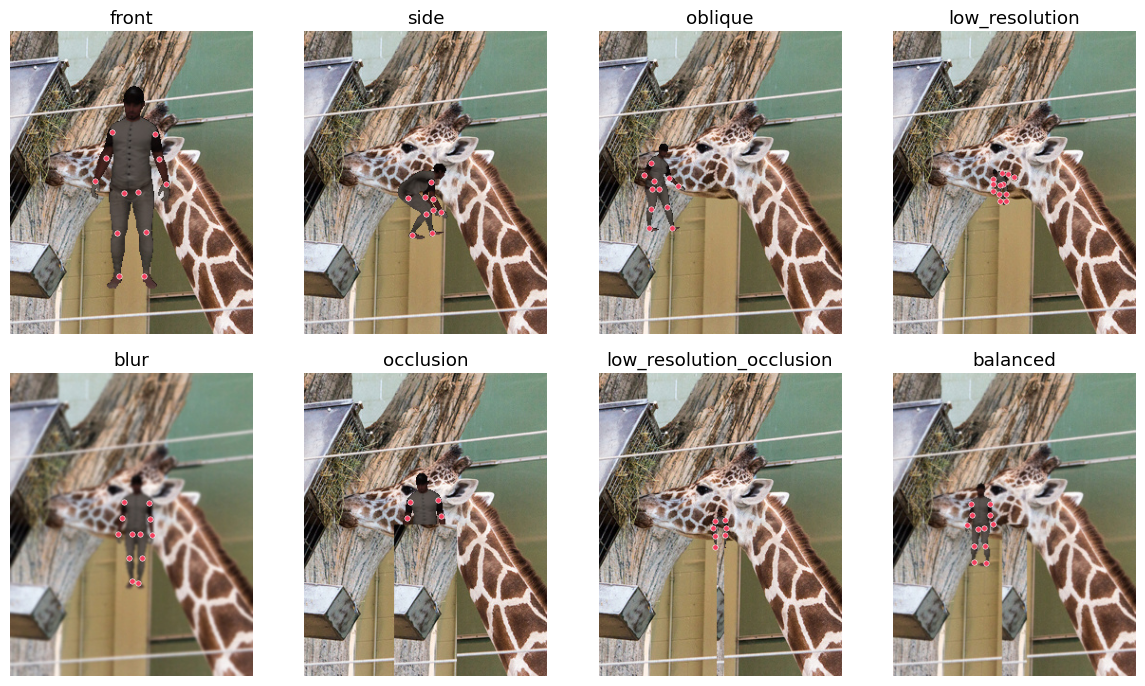

In [5]:
from gavd6_sjepa.research_directions.synthetic_training.data import PoseFrameDataset, load_pose_manifest

source_index = load_pose_manifest(RUN_ROOT / "data/synthetic.csv")
examples = source_index.loc[source_index.role.eq("lesson")].groupby("lesson_id", sort=True).head(1)
gallery = PoseFrameDataset(examples)
columns = 4
rows = (len(gallery) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(12, 3.5 * rows), squeeze=False)
for position, axis in enumerate(axes.flat):
    axis.axis("off")
    if position >= len(gallery):
        continue
    sample = gallery[position]
    visible = sample["visible"]
    axis.imshow(sample["image"])
    axis.scatter(*sample["keypoints"][visible].T, s=15, c="#f43f5e", edgecolors="white", linewidths=.4)
    axis.set_title(str(sample["metadata"]["lesson_id"]))
fig.tight_layout()
plt.show()

Next: [02 · Measure source trials](../../../../../../notebooks/synthetic_training/02_measure_source_trials.ipynb),
once per train/validation student.